In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ============================================================
# Load multiple Vietnam stock files
# ============================================================

vn_path = "../data/vietnam/stock-historical-data"

selected_tickers = ["FPT", "HPG", "VNM", "VCB", "MBB"]

all_files = os.listdir(vn_path)

ticker_files = {}

for ticker in selected_tickers:
    matches = [f for f in all_files if f.startswith(ticker + "-")]
    if len(matches) > 0:
        ticker_files[ticker] = matches[0]

ticker_files

{'FPT': 'FPT-VNINDEX-History.csv',
 'HPG': 'HPG-VNINDEX-History.csv',
 'VNM': 'VNM-VNINDEX-History.csv',
 'VCB': 'VCB-VNINDEX-History.csv',
 'MBB': 'MBB-VNINDEX-History.csv'}

In [4]:
# ============================================================
# Helper function to load and clean one stock
# ============================================================

def load_stock_data(ticker, filename):
    df = pd.read_csv(os.path.join(vn_path, filename))

    df = df.drop(columns=["Unnamed: 0"], errors="ignore")

    df["TradingDate"] = pd.to_datetime(df["TradingDate"], errors="coerce")
    df = df.dropna(subset=["TradingDate"])
    df = df.sort_values("TradingDate").reset_index(drop=True)

    df["Ticker"] = ticker
    df["Daily_Return"] = df["Close"].pct_change()

    return df.dropna().reset_index(drop=True)

In [5]:
stock_data = {}

for ticker, filename in ticker_files.items():
    stock_data[ticker] = load_stock_data(ticker, filename)

stock_data.keys()

dict_keys(['FPT', 'HPG', 'VNM', 'VCB', 'MBB'])

In [6]:
# ============================================================
# Task 4.1 - Profitability scoring
# ============================================================

profit_results = []

lookback_days = 120

for ticker, df_stock in stock_data.items():
    recent = df_stock.tail(lookback_days)

    cumulative_return = (
        recent["Close"].iloc[-1] - recent["Close"].iloc[0]
    ) / recent["Close"].iloc[0]

    avg_daily_return = recent["Daily_Return"].mean()

    profit_results.append({
        "Ticker": ticker,
        "Cumulative_Return_120D": cumulative_return,
        "Average_Daily_Return": avg_daily_return
    })

profit_df = pd.DataFrame(profit_results)

profit_df = profit_df.sort_values(
    "Cumulative_Return_120D",
    ascending=False
).reset_index(drop=True)

profit_df.to_csv(
    "../results/tables/task4_profitability_table.csv",
    index=False
)

profit_df

,Ticker,Cumulative_Return_120D,Average_Daily_Return
0,VCB,0.130593,0.001236
1,VNM,-0.012181,0.000053
2,FPT,-0.061772,-0.000412
3,HPG,-0.150743,-0.000853
4,MBB,-0.270613,-0.002186


In [7]:
# ============================================================
# Task 4.2 - Risk scoring
# ============================================================

risk_results = []

for ticker, df_stock in stock_data.items():
    recent = df_stock.tail(lookback_days)

    volatility = recent["Daily_Return"].std()

    rolling_max = recent["Close"].cummax()
    drawdown = (recent["Close"] - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    risk_results.append({
        "Ticker": ticker,
        "Volatility": volatility,
        "Max_Drawdown": max_drawdown
    })

risk_df = pd.DataFrame(risk_results)

risk_df = risk_df.sort_values(
    "Volatility",
    ascending=True
).reset_index(drop=True)

risk_df.to_csv(
    "../results/tables/task4_risk_table.csv",
    index=False
)

risk_df

,Ticker,Volatility,Max_Drawdown
0,VNM,0.015721,-0.105432
1,FPT,0.017769,-0.231935
2,VCB,0.020213,-0.250302
3,MBB,0.029129,-0.401691
4,HPG,0.035686,-0.491597


In [8]:
# ============================================================
# Combine profitability and risk
# ============================================================

portfolio_df = profit_df.merge(
    risk_df,
    on="Ticker"
)

# Higher return is better
portfolio_df["Return_Rank"] = portfolio_df["Cumulative_Return_120D"].rank(
    ascending=False
)

# Lower volatility is better
portfolio_df["Risk_Rank"] = portfolio_df["Volatility"].rank(
    ascending=True
)

# Combined score: lower is better
portfolio_df["Combined_Score"] = (
    0.6 * portfolio_df["Return_Rank"] +
    0.4 * portfolio_df["Risk_Rank"]
)

portfolio_df = portfolio_df.sort_values("Combined_Score").reset_index(drop=True)

portfolio_df.to_csv(
    "../results/tables/task4_portfolio_scoring_table.csv",
    index=False
)

portfolio_df

,Ticker,Cumulative_Return_120D,Average_Daily_Return,Volatility,Max_Drawdown,Return_Rank,Risk_Rank,Combined_Score
0,VNM,-0.012181,0.000053,0.015721,-0.105432,2.0,1.0,1.6
1,VCB,0.130593,0.001236,0.020213,-0.250302,1.0,3.0,1.8
2,FPT,-0.061772,-0.000412,0.017769,-0.231935,3.0,2.0,2.6
3,HPG,-0.150743,-0.000853,0.035686,-0.491597,4.0,5.0,4.4
4,MBB,-0.270613,-0.002186,0.029129,-0.401691,5.0,4.0,4.6


In [9]:
# ============================================================
# Task 4.3 - Portfolio allocation
# ============================================================

selected_portfolio = portfolio_df.head(3).copy()

# Convert score to allocation weight
# Lower score = higher weight
selected_portfolio["Inverse_Score"] = 1 / selected_portfolio["Combined_Score"]

selected_portfolio["Allocation"] = (
    selected_portfolio["Inverse_Score"] /
    selected_portfolio["Inverse_Score"].sum()
)

selected_portfolio[
    [
        "Ticker",
        "Cumulative_Return_120D",
        "Volatility",
        "Max_Drawdown",
        "Combined_Score",
        "Allocation"
    ]
]

selected_portfolio.to_csv(
    "../results/tables/task4_selected_portfolio_table.csv",
    index=False
)

selected_portfolio

,Ticker,Cumulative_Return_120D,Average_Daily_Return,Volatility,Max_Drawdown,Return_Rank,Risk_Rank,Combined_Score,Inverse_Score,Allocation
0,VNM,-0.012181,0.000053,0.015721,-0.105432,2.0,1.0,1.6,0.625000,0.399317
1,VCB,0.130593,0.001236,0.020213,-0.250302,1.0,3.0,1.8,0.555556,0.354949
2,FPT,-0.061772,-0.000412,0.017769,-0.231935,3.0,2.0,2.6,0.384615,0.245734


In [10]:
# Conservative portfolio: prioritize low risk
conservative = portfolio_df.copy()

conservative["Conservative_Score"] = (
    0.3 * conservative["Return_Rank"] +
    0.7 * conservative["Risk_Rank"]
)

conservative = conservative.sort_values("Conservative_Score").head(3)

conservative

,Ticker,Cumulative_Return_120D,Average_Daily_Return,Volatility,Max_Drawdown,Return_Rank,Risk_Rank,Combined_Score,Conservative_Score
0,VNM,-0.012181,0.000053,0.015721,-0.105432,2.0,1.0,1.6,1.3
2,FPT,-0.061772,-0.000412,0.017769,-0.231935,3.0,2.0,2.6,2.3
1,VCB,0.130593,0.001236,0.020213,-0.250302,1.0,3.0,1.8,2.4


In [11]:
# Risk-taking portfolio: prioritize high return
risk_taking = portfolio_df.copy()

risk_taking["Risk_Taking_Score"] = (
    0.8 * risk_taking["Return_Rank"] +
    0.2 * risk_taking["Risk_Rank"]
)

risk_taking = risk_taking.sort_values("Risk_Taking_Score").head(3)

risk_taking

,Ticker,Cumulative_Return_120D,Average_Daily_Return,Volatility,Max_Drawdown,Return_Rank,Risk_Rank,Combined_Score,Risk_Taking_Score
1,VCB,0.130593,0.001236,0.020213,-0.250302,1.0,3.0,1.8,1.4
0,VNM,-0.012181,0.000053,0.015721,-0.105432,2.0,1.0,1.6,1.8
2,FPT,-0.061772,-0.000412,0.017769,-0.231935,3.0,2.0,2.6,2.8


In [12]:
conservative.to_csv(
    "../results/tables/task4_conservative_portfolio_table.csv",
    index=False
)

risk_taking.to_csv(
    "../results/tables/task4_risk_taking_portfolio_table.csv",
    index=False
)

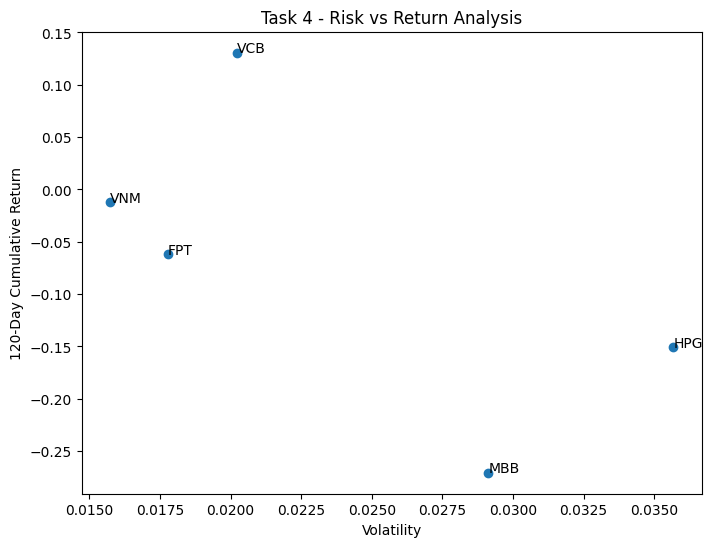

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    portfolio_df["Volatility"],
    portfolio_df["Cumulative_Return_120D"]
)

for _, row in portfolio_df.iterrows():
    plt.text(
        row["Volatility"],
        row["Cumulative_Return_120D"],
        row["Ticker"]
    )

plt.xlabel("Volatility")
plt.ylabel("120-Day Cumulative Return")
plt.title("Task 4 - Risk vs Return Analysis")

plt.savefig(
    "../results/figures/task4_risk_return_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

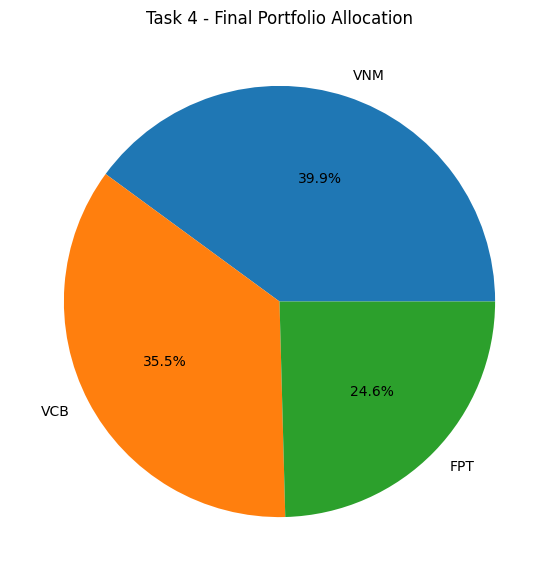

In [14]:
plt.figure(figsize=(7, 7))

plt.pie(
    selected_portfolio["Allocation"],
    labels=selected_portfolio["Ticker"],
    autopct="%1.1f%%"
)

plt.title("Task 4 - Final Portfolio Allocation")

plt.savefig(
    "../results/figures/task4_portfolio_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

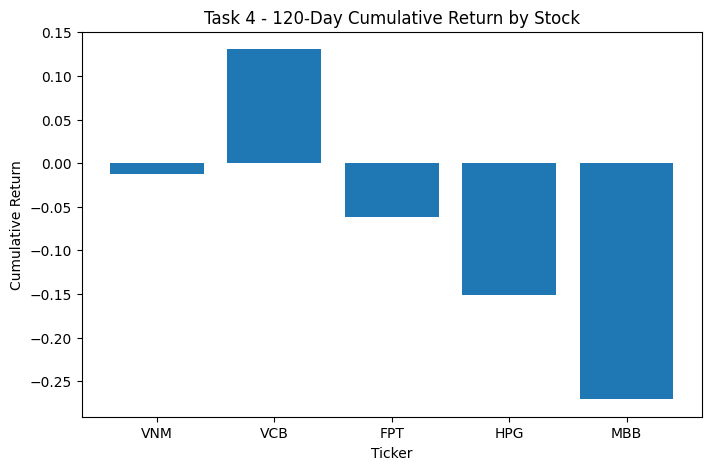

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    portfolio_df["Ticker"],
    portfolio_df["Cumulative_Return_120D"]
)

plt.title("Task 4 - 120-Day Cumulative Return by Stock")
plt.xlabel("Ticker")
plt.ylabel("Cumulative Return")

plt.savefig(
    "../results/figures/task4_cumulative_return_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

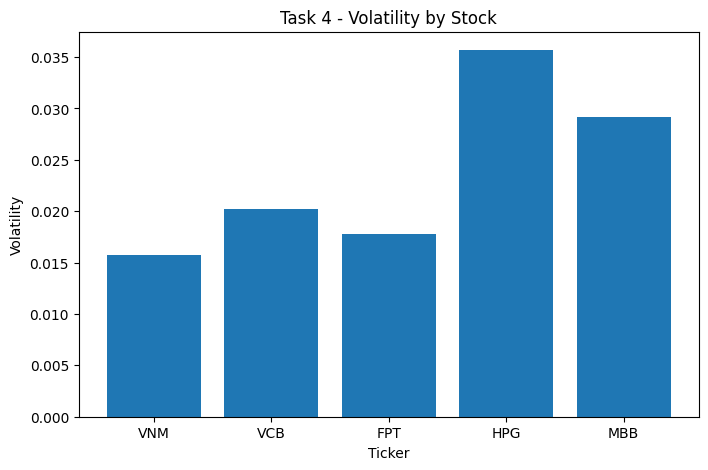

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    portfolio_df["Ticker"],
    portfolio_df["Volatility"]
)

plt.title("Task 4 - Volatility by Stock")
plt.xlabel("Ticker")
plt.ylabel("Volatility")

plt.savefig(
    "../results/figures/task4_volatility_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
task4_summary = pd.DataFrame({
    "Metric": [
        "Best profitability stock",
        "Lowest risk stock",
        "Highest risk stock",
        "Largest portfolio allocation"
    ],
    "Value": [
        profit_df.iloc[0]["Ticker"],
        risk_df.iloc[0]["Ticker"],
        risk_df.iloc[-1]["Ticker"],
        selected_portfolio.sort_values("Allocation", ascending=False).iloc[0]["Ticker"]
    ]
})

task4_summary.to_csv(
    "../results/metrics/task4_summary_metrics.csv",
    index=False
)

task4_summary

,Metric,Value
0,Best profitability stock,VCB
1,Lowest risk stock,VNM
2,Highest risk stock,HPG
3,Largest portfolio allocation,VNM
